In [13]:
import kagglehub

path = kagglehub.dataset_download("akhatova/pcb-defects")

print("Path to dataset files:", path)

Path to dataset files: /home/harshith/.cache/kagglehub/datasets/akhatova/pcb-defects/versions/1


In [20]:
import os

# Path to your dataset (shown in your Kaggle screenshot)
root_dir = "/home/harshith/.cache/kagglehub/datasets/akhatova/pcb-defects/versions/1"

# Path to save trained models or logs
output_dir = "./working/"

print("Dataset path:", root_dir)
print("Output path:", output_dir)

Dataset path: /home/harshith/.cache/kagglehub/datasets/akhatova/pcb-defects/versions/1
Output path: ./working/


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2

import os
import shutil
import random
import xml.etree.ElementTree as ET
import yaml
from pathlib import Path
from collections import Counter

from ultralytics import YOLO
from sklearn.model_selection import KFold

In [21]:
dataset_dir = os.path.join(root_dir, 'PCB_DATASET')

for root, dirs, files in os.walk(dataset_dir):
   for name in dirs:
      print(os.path.join(root, name))

/home/harshith/.cache/kagglehub/datasets/akhatova/pcb-defects/versions/1/PCB_DATASET/Annotations
/home/harshith/.cache/kagglehub/datasets/akhatova/pcb-defects/versions/1/PCB_DATASET/images
/home/harshith/.cache/kagglehub/datasets/akhatova/pcb-defects/versions/1/PCB_DATASET/rotation
/home/harshith/.cache/kagglehub/datasets/akhatova/pcb-defects/versions/1/PCB_DATASET/PCB_USED
/home/harshith/.cache/kagglehub/datasets/akhatova/pcb-defects/versions/1/PCB_DATASET/Annotations/Short
/home/harshith/.cache/kagglehub/datasets/akhatova/pcb-defects/versions/1/PCB_DATASET/Annotations/Missing_hole
/home/harshith/.cache/kagglehub/datasets/akhatova/pcb-defects/versions/1/PCB_DATASET/Annotations/Mouse_bite
/home/harshith/.cache/kagglehub/datasets/akhatova/pcb-defects/versions/1/PCB_DATASET/Annotations/Spur
/home/harshith/.cache/kagglehub/datasets/akhatova/pcb-defects/versions/1/PCB_DATASET/Annotations/Open_circuit
/home/harshith/.cache/kagglehub/datasets/akhatova/pcb-defects/versions/1/PCB_DATASET/Annot

In [22]:
def count_files_in_folder(folder_path):
    files = os.listdir(folder_path)

    num_files = len(files)

    return num_files

In [23]:
subfolders = ['Missing_hole', 'Mouse_bite',
              'Open_circuit', 'Short', 'Spur', 'Spurious_copper']

images_dir = os.path.join(dataset_dir, 'images')
annot_dir = os.path.join(dataset_dir, 'Annotations')

for subfolder in subfolders:
    images_path = os.path.join(images_dir, subfolder)
    annot_path = os.path.join(annot_dir, subfolder)

    print(f'{subfolder:<15} \t\
            {count_files_in_folder(images_path)} images \t\
            {count_files_in_folder(annot_path)} annotations')

Missing_hole    	            115 images 	            115 annotations
Mouse_bite      	            115 images 	            115 annotations
Open_circuit    	            116 images 	            116 annotations
Short           	            116 images 	            116 annotations
Spur            	            115 images 	            115 annotations
Spurious_copper 	            116 images 	            116 annotations


In [24]:
def parse_xml(xml_file):
    tree = ET.parse(xml_file)
    root = tree.getroot()
    data = []

    filename = root.find('filename').text
    width = int(root.find('size/width').text)
    height = int(root.find('size/height').text)

    for obj in root.findall('object'):
        name = obj.find('name').text
        xmin = int(obj.find('bndbox/xmin').text)
        ymin = int(obj.find('bndbox/ymin').text)
        xmax = int(obj.find('bndbox/xmax').text)
        ymax = int(obj.find('bndbox/ymax').text)

        data.append({
            'filename': filename,
            'width': width,
            'height': height,
            'class': name,
            'xmin': xmin,
            'ymin': ymin,
            'xmax': xmax,
            'ymax': ymax
        })

    return data

In [25]:
all_data = []

# Recursively traverse subdirectories
for root, dirs, files in os.walk(annot_dir):
    for name in files:
        if name.endswith('.xml'):
            xml_path = os.path.join(root, name)
            all_data.extend(parse_xml(xml_path))

In [26]:
annot_df = pd.DataFrame(all_data)
annot_df.head()

,filename,width,height,class,xmin,ymin,xmax,ymax
0,07_short_05.jpg,2904,1921,short,1896,634,1992,717
1,07_short_05.jpg,2904,1921,short,1418,908,1537,998
2,07_short_05.jpg,2904,1921,short,2184,610,2313,691
3,07_short_05.jpg,2904,1921,short,1453,463,1584,546
4,07_short_05.jpg,2904,1921,short,2113,451,2217,534


In [27]:
def get_subfolder(image_name):
    if 'missing' in image_name.split('_'):
        return 'Missing_hole'
    if 'mouse' in image_name.split('_'):
        return 'Mouse_bite'
    if 'open' in image_name.split('_'):
        return 'Open_circuit'
    if 'short' in image_name.split('_'):
        return 'Short'
    if 'spur' in image_name.split('_'):
        return 'Spur'
    if 'spurious' in image_name.split('_'):
        return 'Spurious_copper'

In [28]:
def visualize_annotations(image_name, images_dir, annot_df, is_subfolder=False):
    # Construct path for image
    if is_subfolder:
        image_path = os.path.join(
            images_dir, get_subfolder(image_name), image_name)
    else:
        image_path = os.path.join(images_dir, image_name)

    # Read image
    image = cv2.imread(image_path)

    # Filter annotations for the current image
    annotations = annot_df[annot_df['filename'] == image_name]

    # Draw bounding boxes on the image
    for _, annot in annotations.iterrows():
        xmin, ymin, xmax, ymax = annot['xmin'], annot['ymin'], annot['xmax'], annot['ymax']
        class_label = annot['class']

        # Check if confidence column exists
        confidence = annot.get('confidence')
        if confidence is not None:
            class_label += f" ({confidence:.2f})"

        color = (255, 255, 255)
        cv2.rectangle(image, (xmin, ymin), (xmax, ymax), color, 3)

        # Add background to the text
        text_size = cv2.getTextSize(
            class_label, cv2.FONT_HERSHEY_SIMPLEX, 1.5, 2)[0]
        cv2.rectangle(image, (xmin, ymin - text_size[1] - 5),
                      (xmin + text_size[0], ymin - 1), color, -1)

        # Add text
        cv2.putText(image, class_label, (xmin, ymin - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 0, 0), 2)

    # Convert BGR image to RGB (Matplotlib expects RGB)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Plot the image with annotations
    plt.figure(figsize=(18, 10))
    plt.imshow(image_rgb)
    plt.axis('off')
    plt.title('Annotations')
    plt.text(10, image_rgb.shape[0] + 100, f'Image: {image_name}',
             color='black', fontsize=11, ha='left')
    plt.show()

    return image

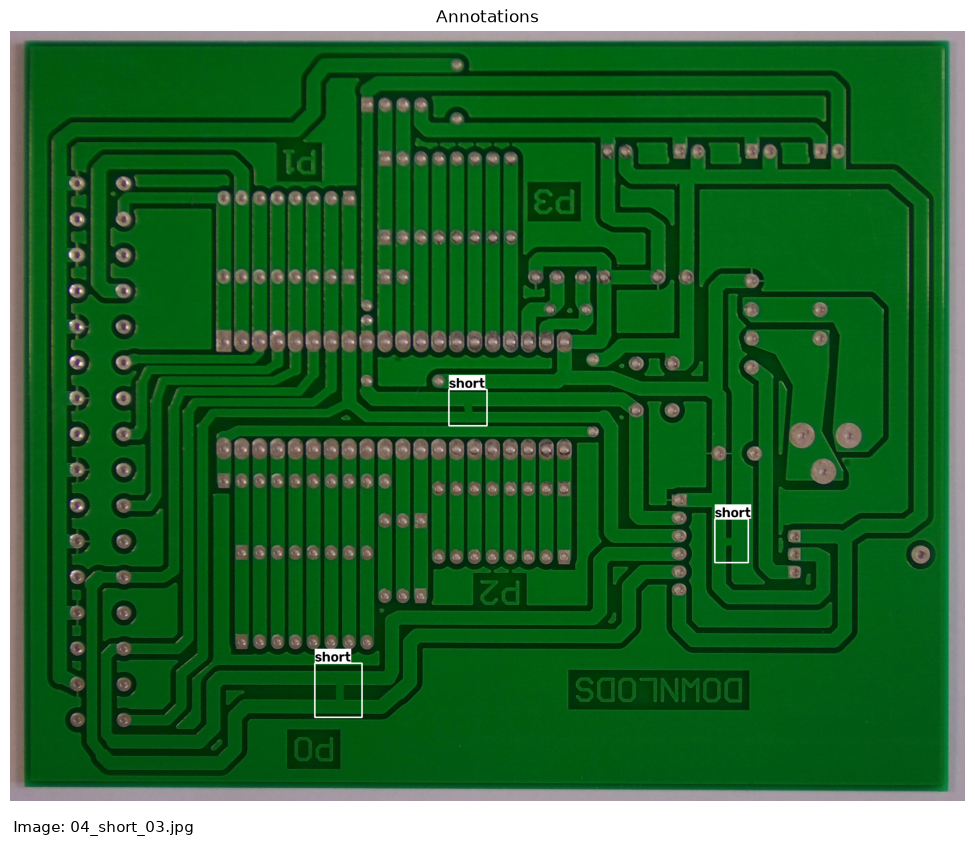

array([[[159, 144, 165],
        [153, 139, 157],
        [155, 142, 158],
        ...,
        [170, 157, 173],
        [168, 155, 171],
        [168, 155, 171]],

       [[154, 139, 160],
        [153, 139, 157],
        [152, 139, 155],
        ...,
        [168, 155, 171],
        [167, 154, 170],
        [169, 156, 172]],

       [[156, 141, 162],
        [159, 145, 163],
        [155, 142, 158],
        ...,
        [166, 153, 169],
        [167, 154, 170],
        [169, 156, 172]],

       ...,

       [[159, 146, 162],
        [159, 146, 162],
        [159, 146, 162],
        ...,
        [161, 151, 164],
        [162, 152, 165],
        [162, 152, 164]],

       [[160, 147, 163],
        [159, 146, 162],
        [158, 145, 161],
        ...,
        [161, 151, 164],
        [161, 151, 164],
        [159, 151, 162]],

       [[163, 150, 166],
        [161, 148, 164],
        [159, 146, 162],
        ...,
        [161, 151, 164],
        [160, 150, 163],
        [158, 150, 161]]

In [29]:
image_name = '04_short_03.jpg'
visualize_annotations(image_name, images_dir, annot_df, is_subfolder=True)

In [30]:
def resize_images(input_dir, output_dir, target_size=(768, 768)):
    os.makedirs(output_dir, exist_ok=True)

    target_w, target_h = target_size

    for root, _, files in os.walk(input_dir):
        for file in files:
            if file.lower().endswith('.jpg'):
                image_path = os.path.join(root, file)
                img = cv2.imread(image_path)

                h, w = img.shape[:2]
                scale = min(target_w / w, target_h / h)

                new_w = int(w * scale)
                new_h = int(h * scale)

                resized = cv2.resize(img, (new_w, new_h),
                                     interpolation=cv2.INTER_LINEAR)

                canvas = np.full((target_h, target_w, 3), 114, dtype=np.uint8)
                canvas[:new_h, :new_w] = resized

                output_path = os.path.join(output_dir, file)
                cv2.imwrite(output_path, canvas)


# YOU MUST SAVE IN A WRITABLE DIRECTORY
resized_img_dir = "./working/images_resized"

resize_images(images_dir, resized_img_dir)

In [31]:
def resize_annotations(annot_df, target_size=(768, 768)):
    target_w, target_h = target_size
    all_data = []

    for _, row in annot_df.iterrows():
        orig_w = row['width']
        orig_h = row['height']

        # same scale factor used in resize_images()
        scale = min(target_w / orig_w, target_h / orig_h)

        # no padding offset because we place image at top-left (0,0)
        pad_x = 0
        pad_y = 0

        # apply scale
        xmin = int(row['xmin'] * scale + pad_x)
        ymin = int(row['ymin'] * scale + pad_y)
        xmax = int(row['xmax'] * scale + pad_x)
        ymax = int(row['ymax'] * scale + pad_y)

        all_data.append({
            'filename': row['filename'],
            'width': target_w,
            'height': target_h,
            'class': row['class'],
            'xmin': xmin,
            'ymin': ymin,
            'xmax': xmax,
            'ymax': ymax
        })

    return pd.DataFrame(all_data)


annot_df_resized = resize_annotations(annot_df)
annot_df_resized.head()

,filename,width,height,class,xmin,ymin,xmax,ymax
0,07_short_05.jpg,768,768,short,501,167,526,189
1,07_short_05.jpg,768,768,short,375,240,406,263
2,07_short_05.jpg,768,768,short,577,161,611,182
3,07_short_05.jpg,768,768,short,384,122,418,144
4,07_short_05.jpg,768,768,short,558,119,586,141


In [32]:
# Create the output directory (MUST BE IN kaggle/working/)
output_dir = "./working/output"
os.makedirs(output_dir, exist_ok=True)

print("Output directory:", output_dir)

Output directory: ./working/output


In [33]:
def convert_to_yolo_labels(annotation_df, classes, target_size=(768, 768)):
    yolo_labels = []

    for _, annot in annotation_df.iterrows():
        filename = annot['filename']
        width, height = annot['width'], annot['height']
        class_name = annot['class']
        xmin, ymin, xmax, ymax = annot['xmin'], annot['ymin'], annot['xmax'], annot['ymax']

        # Convert bounding box coordinates to YOLO format
        x_center = (xmin + xmax) / (2 * width)
        y_center = (ymin + ymax) / (2 * height)
        bbox_width = (xmax - xmin) / width
        bbox_height = (ymax - ymin) / height

        class_index = classes.index(class_name)

        # Append to YOLO labels list
        yolo_labels.append((filename, class_index, x_center,
                           y_center, bbox_width, bbox_height))

    return yolo_labels


classes = ['missing_hole', 'mouse_bite', 'open_circuit',
           'short', 'spur', 'spurious_copper']
yolo_labels = convert_to_yolo_labels(annot_df_resized, classes)

In [34]:
def split_images_and_labels(images_dir, labels, output_dir, train_split=0.95, val_split=0.05):
    # os.makedirs(output_dir, exist_ok=True)
    os.makedirs(os.path.join(output_dir, 'images/train'), exist_ok=True)
    os.makedirs(os.path.join(output_dir, 'images/val'), exist_ok=True)
    os.makedirs(os.path.join(output_dir, 'images/test'), exist_ok=True)
    os.makedirs(os.path.join(output_dir, 'labels/train'), exist_ok=True)
    os.makedirs(os.path.join(output_dir, 'labels/val'), exist_ok=True)
    os.makedirs(os.path.join(output_dir, 'labels/test'), exist_ok=True)

    # Group labels by image filename
    image_labels = {}
    for label in labels:
        filename, class_index, x_center, y_center, bbox_width, bbox_height = label
        if filename not in image_labels:
            image_labels[filename] = []
        image_labels[filename].append(label)

    # Shuffle the image filenames
    image_filenames = list(image_labels.keys())
    random.shuffle(image_filenames)

    # Split the dataset
    num_images = len(image_filenames)
    num_train = int(num_images * train_split)
    num_val = int(num_images * val_split)

    train_filenames = image_filenames[:num_train]
    val_filenames = image_filenames[num_train:num_train + num_val]
    test_filenames = image_filenames[num_train + num_val:]

    # Write train, val, test images and labels
    for dataset, filenames in [('train', train_filenames), ('val', val_filenames), ('test', test_filenames)]:
        for filename in filenames:
            labels = image_labels[filename]
            with open(os.path.join(output_dir, f'labels/{dataset}/{os.path.splitext(filename)[0]}.txt'), 'w') as label_file:
                for label in labels:
                    _, class_index, x_center, y_center, bbox_width, bbox_height = label
                    label_file.write(
                        f"{class_index} {x_center} {y_center} {bbox_width} {bbox_height}\n")
            # Copy images to corresponding folders
            shutil.copy(os.path.join(images_dir, filename), os.path.join(
                output_dir, f'images/{dataset}/{filename}'))


split_images_and_labels(resized_img_dir, yolo_labels, output_dir)

In [35]:
dataset_path = Path(output_dir)
# all data in 'labels'
labels = sorted(dataset_path.rglob("*labels/train/*.txt"))

In [36]:
cls_idx = list(range(len(classes)))
print(list(zip(classes, cls_idx)))

[('missing_hole', 0), ('mouse_bite', 1), ('open_circuit', 2), ('short', 3), ('spur', 4), ('spurious_copper', 5)]


In [37]:
indx = [l.stem for l in labels]  # uses base filename as ID (no extension)
labels_df = pd.DataFrame([], columns=cls_idx, index=indx)

In [38]:
for label in labels:
    lbl_counter = Counter()

    with open(label, 'r') as lf:
        lines = lf.readlines()

    for l in lines:
        # classes for YOLO label uses integer at first position of each line
        lbl_counter[int(l.split(' ')[0])] += 1

    labels_df.loc[label.stem] = lbl_counter

labels_df = labels_df.fillna(0.0)  # replace `nan` values with `0.0`
labels_df.head()

,0,1,2,3,4,5
01_missing_hole_01,3.0,0.0,0.0,0.0,0.0,0.0
01_missing_hole_02,3.0,0.0,0.0,0.0,0.0,0.0
01_missing_hole_03,3.0,0.0,0.0,0.0,0.0,0.0
01_missing_hole_04,3.0,0.0,0.0,0.0,0.0,0.0
01_missing_hole_05,4.0,0.0,0.0,0.0,0.0,0.0


In [39]:
ksplit = 3
# setting random_state for repeatable results
kf = KFold(n_splits=ksplit, shuffle=True, random_state=20)

kfolds = list(kf.split(labels_df))

In [41]:
folds = [f'split_{n}' for n in range(1, ksplit + 1)]
folds_df = pd.DataFrame(index=indx, columns=folds)

for idx, (train, val) in enumerate(kfolds, 1):
    col = f'split_{idx}'
    folds_df.loc[labels_df.index[train], col] = 'train'
    folds_df.loc[labels_df.index[val], col] = 'val'

In [42]:
fold_lbl_distrb = pd.DataFrame(index=folds, columns=cls_idx)

for n, (train_indices, val_indices) in enumerate(kfolds, start=1):
    train_totals = labels_df.iloc[train_indices].sum()
    val_totals = labels_df.iloc[val_indices].sum()

    # To avoid division by zero, we add a small value (1E-7) to the denominator
    ratio = val_totals / (train_totals + 1E-7)
    fold_lbl_distrb.loc[f'split_{n}'] = ratio

fold_lbl_distrb

,0,1,2,3,4,5
split_1,0.360563,0.537931,0.327273,0.507987,0.737226,0.528125
split_2,0.518868,0.670412,0.547703,0.470405,0.340845,0.624585
split_3,0.648464,0.331343,0.665399,0.522581,0.473684,0.369748


In [43]:
images = sorted(dataset_path.rglob("*images/train/*.jpg"))

# Create the necessary directories and dataset YAML files (unchanged)
save_path = Path(dataset_path / f'{ksplit}fold_crossval')
save_path.mkdir(parents=True, exist_ok=True)
ds_yamls = []

for split in folds_df.columns:
    # Create directories
    split_dir = save_path / split
    split_dir.mkdir(parents=True, exist_ok=True)
    (split_dir / 'train' / 'images').mkdir(parents=True, exist_ok=True)
    (split_dir / 'train' / 'labels').mkdir(parents=True, exist_ok=True)
    (split_dir / 'val' / 'images').mkdir(parents=True, exist_ok=True)
    (split_dir / 'val' / 'labels').mkdir(parents=True, exist_ok=True)

    # Create dataset YAML files
    dataset_yaml = split_dir / f'{split}_dataset.yaml'
    ds_yamls.append(dataset_yaml)

    with open(dataset_yaml, 'w') as ds_y:
        yaml.safe_dump({
            'path': split_dir.as_posix(),
            'train': 'train',
            'val': 'val',
            'names': classes
        }, ds_y)

In [44]:
for image, label in zip(images, labels):
    for split, k_split in folds_df.loc[image.stem].items():
        # Destination directory
        img_to_path = save_path / split / k_split / 'images'
        lbl_to_path = save_path / split / k_split / 'labels'

        # Copy image and label files to new directory
        shutil.copy(image, img_to_path / image.name)
        shutil.copy(label, lbl_to_path / label.name)

In [45]:
folds_df.to_csv(save_path / "kfold_datasplit.csv")
fold_lbl_distrb.to_csv(save_path / "kfold_label_distribution.csv")

In [46]:
from ultralytics import YOLO
import torch
import gc

results = {}

model_name = "yolov8m.pt"
batch = 8
epochs = 180
imgsz = 768
save_period = 5
project = "pcb_m_sota_v8_clean_fixed"

for k in range(ksplit):
    print(f"\n🔵 TRAINING FOLD {k+1}/{ksplit}\n")

    model = YOLO(model_name)
    dataset_yaml = ds_yamls[k]

    model.train(
    data=dataset_yaml,
    epochs=epochs,
    batch=batch,
    imgsz=imgsz,

    # ---- DEVICE ----
    device=0,
    amp=True,

    # ---- LEARNING ----
    lr0=0.002,
    lrf=0.0001,
    momentum=0.95,
    weight_decay=0.0005,
    warmup_epochs=4,
    warmup_momentum=0.9,

    # ---- LOSS ----
    box=7.0,
    cls=1.0,

    # ---- AUGMENTATION ----
    mosaic=0.8,
    mixup=0.0,
    erasing=0.35,
    copy_paste=0.15,
    auto_augment="randaugment",

    hsv_h=0.02,
    hsv_s=0.8,
    hsv_v=0.5,

    translate=0.12,
    scale=0.55,
    fliplr=0.5,
    perspective=0.0005,

    # ---- DETECTION / IMAGE ----
    multi_scale=False,

    # ---- SYSTEM ----
    workers=4,
    cache=False,

    # ---- TRAINING CONTROL ----
    patience=30,

    # ---- SAVE / LOG ----
    project=project,
    name=f"fold_{k}",
    save_period=5,
    verbose=True,
)

    results[k] = model.metrics

    del model
    gc.collect()
    torch.cuda.empty_cache()


🔵 TRAINING FOLD 1/3

Ultralytics 8.4.121 🚀 Python-3.11.16 torch-2.11.0+cu128 CUDA:0 (NVIDIA RTX PRO 4000 Blackwell Generation Laptop GPU, 16303MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.0, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=1.0, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.15, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=working/output/3fold_crossval/split_1/split_1_dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=180, erasing=0.35, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.02, hsv_s=0.8, hsv_v=0.5, imgsz=768, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.002, lrf=0.0001, mask_ratio=4, max_det=300, mixup=0.0, mode=train, m

In [ ]:
import pandas as pd

train_dir = "runs/detect/pcb_m_sota_v8_clean_fixed/fold_2"  # or f"{project}/run_m_sota", check the actual save path printed during training
results_csv_path = os.path.join(train_dir, "results.csv")

results_df = pd.read_csv(results_csv_path)
results_df.columns = results_df.columns.str.strip()  # ultralytics CSVs sometimes have leading spaces in headers

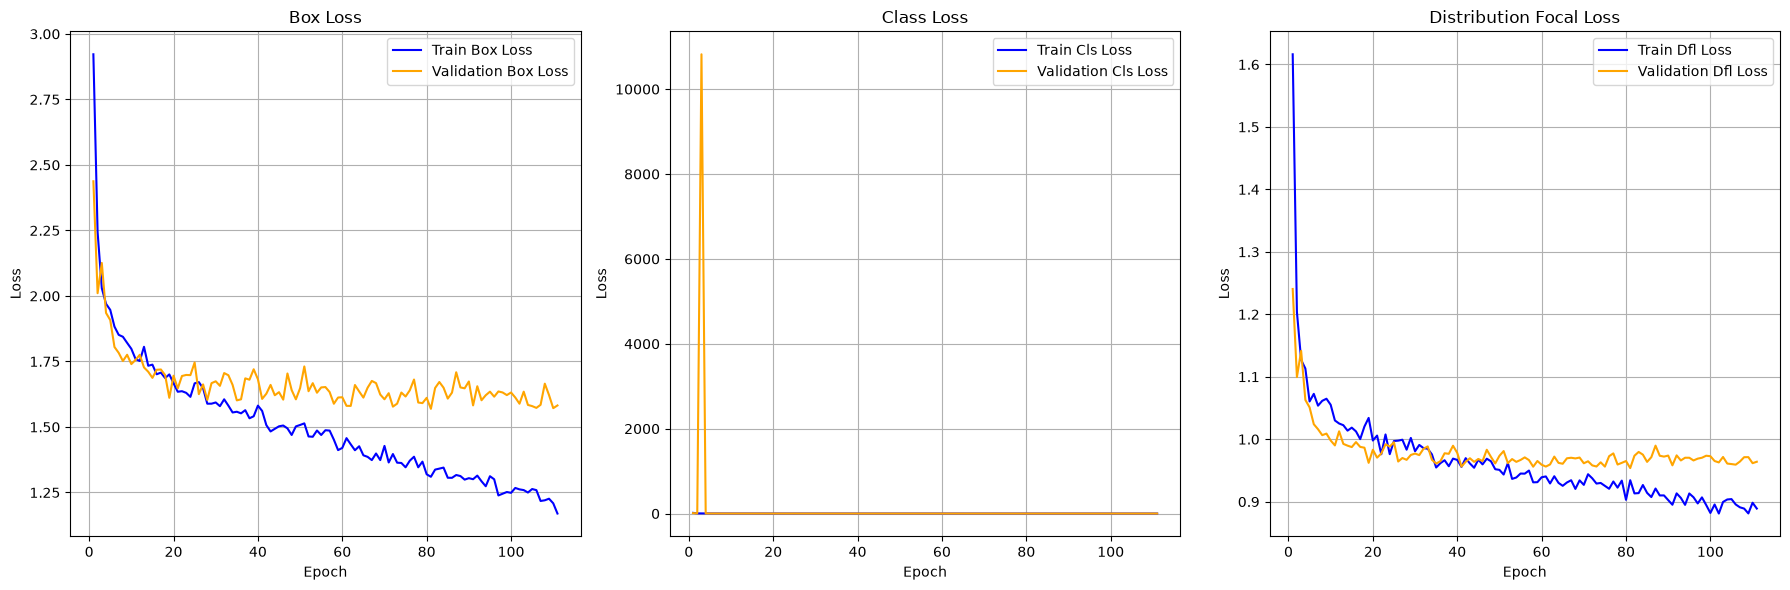

In [52]:
epochs = results_df['epoch']
train_box_loss = results_df['train/box_loss']
val_box_loss = results_df['val/box_loss']
train_cls_loss = results_df['train/cls_loss']
val_cls_loss = results_df['val/cls_loss']
train_dfl_loss = results_df['train/dfl_loss']
val_dfl_loss = results_df['val/dfl_loss']

# Create a figure with three subplots
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Plot box loss
axs[0].plot(epochs, train_box_loss, label='Train Box Loss', color='blue')
axs[0].plot(epochs, val_box_loss, label='Validation Box Loss', color='orange')
axs[0].set_title('Box Loss')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Loss')
axs[0].legend()
axs[0].grid(True)

# Plot cls loss
axs[1].plot(epochs, train_cls_loss, label='Train Cls Loss', color='blue')
axs[1].plot(epochs, val_cls_loss, label='Validation Cls Loss', color='orange')
axs[1].set_title('Class Loss')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Loss')
axs[1].legend()
axs[1].grid(True)

# Plot dfl loss
axs[2].plot(epochs, train_dfl_loss, label='Train Dfl Loss', color='blue')
axs[2].plot(epochs, val_dfl_loss, label='Validation Dfl Loss', color='orange')
axs[2].set_title('Distribution Focal Loss')
axs[2].set_xlabel('Epoch')
axs[2].set_ylabel('Loss')
axs[2].legend()
axs[2].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# ------------------------------
# Load the trained model
# ------------------------------
train_dir = "runs/detect/pcb_m_sota_v8_clean_fixed/fold_2"
best_model_path = os.path.join(train_dir, "weights/best.pt")
model = YOLO(best_model_path)

print("Using model:", best_model_path)

# ------------------------------
# Run inference on val images
# ------------------------------
test_data_dir = os.path.join(output_dir, "images/val")

metrics = model(source=test_data_dir, imgsz=640, conf=0.25,
                save=True, save_txt=True, save_conf=True)

In [ ]:
# -----------------------------------
# Save predictions safely in working/
# (best.pt lives under train_dir/weights, not inside the
#  prediction output dir, which only contains images/labels)
# -----------------------------------
predict_dir = str(metrics[0].save_dir)
dest_predict_dir = "./working/results/predict2"

os.makedirs(dest_predict_dir, exist_ok=True)

shutil.copytree(predict_dir, dest_predict_dir, dirs_exist_ok=True)

print("✔ Predictions saved to:", dest_predict_dir)

In [ ]:
def yolo_to_original_annot(image_name, yolo_labels, annot_df, classes):
    original_annot = []

    for yolo_label in yolo_labels:
        # Extract original width and height from annotation DataFrame
        original_size = annot_df.loc[annot_df['filename']
                                     == image_name, ['width', 'height']].iloc[0]
        original_width, original_height = original_size['width'], original_size['height']

        # Extract YOLO label components
        class_index, x_center, y_center, bbox_width, bbox_height, confidence = yolo_label

        # Scale bounding box coordinates and dimensions to original size
        original_x_center = x_center * original_width
        original_y_center = y_center * original_height
        original_bbox_width = bbox_width * original_width
        original_bbox_height = bbox_height * original_height

        # Calculate original bounding box coordinates
        original_x_min = original_x_center - original_bbox_width / 2
        original_y_min = original_y_center - original_bbox_height / 2
        original_x_max = original_x_center + original_bbox_width / 2
        original_y_max = original_y_center + original_bbox_height / 2

        # Append original annotation to list
        original_annot.append({
            'filename': image_name,
            'width': int(original_width),
            'height': int(original_height),
            'class': classes[int(class_index)],
            'xmin': int(original_x_min),
            'ymin': int(original_y_min),
            'xmax': int(original_x_max),
            'ymax': int(original_y_max),
            'confidence': confidence
        })

    return pd.DataFrame(original_annot)

In [ ]:
def read_yolo_labels_from_file(file_path):
    labels = []
    with open(file_path, 'r') as file:
        for line in file:
            values = line.strip().split()
            values = [float(value) for value in values]
            labels.append(values)
    return labels


image_name = '04_missing_hole_10.jpg'
file_path = os.path.join(
    dest_predict_dir, 'labels', os.path.splitext(image_name)[0] + '.txt')
yolo_labels = read_yolo_labels_from_file(file_path)

yolo_labels

In [ ]:
pred_annot_df = yolo_to_original_annot(
    image_name, yolo_labels, annot_df, classes)
pred_annot_df.head()

In [ ]:
visualize_annotations(image_name, images_dir,
                      pred_annot_df, is_subfolder=True)

## Held-out evaluation and portable export

The three folds were each trained with a different held-out validation split (standard k-fold CV), so the per-epoch `val/*` metrics already logged in `results.csv` are genuine held-out numbers, not train-set leakage. The separate `images/test` split created earlier only ended up with 1 image (train_split=0.95 + val_split=0.05 leaves almost nothing for test), so it isn't usable as an independent test set on its own.

Below: compare the 3 folds, formally re-run `.val()` on the best fold's held-out split, then export a clean, self-contained bundle (`.pt` + `.onnx` + class names + a standalone inference script) that another machine can use without any of the training code above.

In [ ]:
import glob

fold_dirs = sorted(glob.glob("runs/detect/pcb_m_sota_v8_clean_fixed/fold_*"))
fold_scores = {}
for fd in fold_dirs:
    df = pd.read_csv(os.path.join(fd, "results.csv"))
    df.columns = df.columns.str.strip()
    fold_scores[fd] = df["metrics/mAP50(B)"].iloc[-1]

for fd, score in fold_scores.items():
    print(f"{fd}: mAP50={score:.4f}")

best_fold_dir = max(fold_scores, key=fold_scores.get)
best_fold_index = fold_dirs.index(best_fold_dir)
print("\nBest fold:", best_fold_dir)

In [ ]:
# Formal held-out evaluation: re-run YOLO's own .val() pipeline (confusion
# matrix, per-class PR curves, etc.) against the best fold's val split, which
# that fold's training never saw.
eval_model = YOLO(os.path.join(best_fold_dir, "weights", "best.pt"))
val_metrics = eval_model.val(data=str(ds_yamls[best_fold_index]), split="val")

print("Precision:", val_metrics.box.mp)
print("Recall:", val_metrics.box.mr)
print("mAP50:", val_metrics.box.map50)
print("mAP50-95:", val_metrics.box.map)

In [ ]:
# -----------------------------------------------------------------
# Build a clean, portable deploy bundle: everything another machine
# needs to run inference, and nothing it doesn't (no dataset, no
# training checkpoints from other epochs, no cross-val scaffolding).
# -----------------------------------------------------------------
export_dir = "./working/deploy"
os.makedirs(export_dir, exist_ok=True)

best_weights = os.path.join(best_fold_dir, "weights", "best.pt")
deploy_model = YOLO(best_weights)

# ONNX: portable, runs with just `onnxruntime` — no torch/ultralytics
# needed on the target machine if you use it directly.
onnx_path = deploy_model.export(format="onnx", imgsz=640, simplify=True)

shutil.copy(best_weights, os.path.join(export_dir, "best.pt"))
shutil.copy(onnx_path, os.path.join(export_dir, "best.onnx"))

with open(os.path.join(export_dir, "classes.txt"), "w") as f:
    f.write("\n".join(classes))

print("Deploy bundle ready at:", export_dir)
print(os.listdir(export_dir))

In [ ]:
predict_script = '''"""
Standalone PCB defect detector inference.
On the target machine: pip install ultralytics onnxruntime
(ultralytics loads either best.pt or best.onnx and handles
pre/post-processing + NMS for you - no training code needed.)

Runs on CPU by default so it works on any machine regardless of
GPU/CUDA setup. If the target machine has a matching CUDA + cuDNN
install, change DEVICE below to 0 for GPU inference.

Usage: python predict.py path/to/image.jpg
"""
import sys
from ultralytics import YOLO

MODEL_PATH = "best.onnx"  # or "best.pt"
DEVICE = "cpu"


def main(image_path):
    model = YOLO(MODEL_PATH, task="detect")
    results = model(image_path, conf=0.25, device=DEVICE)
    for r in results:
        r.save(filename="prediction.jpg")
        for box in r.boxes:
            cls_name = model.names[int(box.cls)]
            conf = float(box.conf)
            print(f"{cls_name}: {conf:.2f}")
    print("Annotated image saved to prediction.jpg")


if __name__ == "__main__":
    main(sys.argv[1])
'''

with open(os.path.join(export_dir, "predict.py"), "w") as f:
    f.write(predict_script)

readme = f'''PCB Defect Detector - deploy bundle
====================================

Files:
  best.pt      - native ultralytics/PyTorch weights
  best.onnx    - portable ONNX export (use this unless you need .pt specifically)
  classes.txt  - class names, in label-index order
  predict.py   - minimal standalone inference script (CPU by default)

Setup on the new machine:
  pip install ultralytics onnxruntime
  python predict.py your_image.jpg

Classes: {", ".join(classes)}
'''

with open(os.path.join(export_dir, "README.txt"), "w") as f:
    f.write(readme)

print("Wrote predict.py and README.txt to", export_dir)

In [ ]:
from IPython.display import FileLink

zip_base = "pcb_defect_model"
shutil.make_archive(zip_base, "zip", export_dir)

zip_path = f"{zip_base}.zip"
size_mb = os.path.getsize(zip_path) / (1024 * 1024)
print(f"✔ {zip_path} created ({size_mb:.2f} MB)")
print("Copy this single file to the other machine, unzip it, and follow README.txt")
display(FileLink(zip_path))

In [ ]:
import os
from IPython.display import FileLink

!rm -f *.zip
!rm -f *.7z

print("zipping outputs")

!zip -r -q final_data.zip output runs results

if os.path.exists("final_data.zip"):
    size_mb = os.path.getsize("final_data.zip") / (1024 * 1024)
    print(f"\nzip created ({size_mb:.2f} MB).")
    display(FileLink('final_data.zip'))
else:
    print("\nerror: creation failed")